In [2]:
from Scripts.Mission_Profile.mission_profile import MissionProfileLinearAcc

import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.material_properties import Gravity
from Scripts.Mass_Analysis.drone_battery import Battery
from Scripts.Mission_Profile.drone_power import BatterySystem
from Scripts.drone_geometry import DroneGeometry
from Scripts.Finite_Elements.drone_fea import DroneFEA
from Scripts.Mass_Analysis.drone_mass import DroneMass
from Scripts.Mission_Profile.drone_power import DronePower

q = 0.05 * 2.56 * 0.05


air_density = 1.225e-12
drag_coeff = 0.256
Propeller_radius = 406.4
Propeller_spacing = 25
propeller_max_RPM = 3068

m1 = MissionProfileLinearAcc("profile")


m1 = MissionProfileLinearAcc("profile")

m1.add_segment(40, "Takeoff")

m1.add_segment(40, "Climb1")
m1.add_segment(40, "Climb2")

m1.add_segment(200, "cruise1")
m1.add_segment(200, "cruise2")

m1.add_segment(40, "decent1")
m1.add_segment(40, "decent2")

m1.add_segment(40, "land")

# Takeoff
m1.add_constraint(0, "x", 0)
m1.add_constraint(0, "y", 0)
m1.add_constraint(0, "vx", 0)
m1.add_constraint(0, "vy", 0)
m1.add_constraint(0, "ax", 0)
m1.add_constraint(0, "ay", 0)

# Cruise
m1.add_constraint(500000, "x", 3)
m1.add_constraint(560000, "y", 3)
m1.add_constraint(0, "ax", 3)
m1.add_constraint(0, "ay", 3)

m1.add_constraint(2800000, "x", 4)
m1.add_constraint(560000, "y", 4)

m1.add_constraint(5100000, "x", 5)
m1.add_constraint(560000, "y", 5)
m1.add_constraint(0, "ax", 5)
m1.add_constraint(0, "ay", 5)

# Decent
m1.add_constraint(5600000, "x", 8)
m1.add_constraint(0, "y", 8)
m1.add_constraint(0, "vx", 8)
m1.add_constraint(0, "vy", 8)
m1.add_constraint(0, "ax", 8)
m1.add_constraint(0, "ay", 8)

# spacing between propellers
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)
hub_radius = 200
hub_side_length = 2 * hub_radius * math.tan(math.pi/8)
print("hub side length: ", hub_side_length)

battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

arm_d,arm_t,strut_d,strut_t,strut_dist = [29, 1.6, 13, 1.6, 660]
arm_beam_properties = BeamType("annulus", [arm_d + arm_t * 2, arm_d], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_d + strut_t * 2, strut_d], "Carbon Fiber", "strut_beam")
hub_beam_properties = BeamType("i_beam", [hub_side_length*(2/3),29,2,2], "Carbon Fiber", "hub_beam")

drone_geometry = DroneGeometry("drone", arm_length, hub_radius, strut_dist, 8, arm_beam_properties, strut_beam_properties, hub_beam_properties, 5,[battery_1, battery_2])

drone_mass = DroneMass(drone_geometry).total_mass + (45 * 10 ** -3)

rev_time = 5
lift_thrust = Gravity * drone_mass / 8
SA = drone_geometry.projected_surface_area

def force_transient(t):
    if t < rev_time:
        return np.array([0, 0, (t/rev_time) * (lift_thrust), 0, 0, 0])
    elif t < rev_time + m1.duration:
        # Calculate force per propeller
        p, v, a = m1.time_solve(t-rev_time)
        return np.array([0, 0, (2 * (v[1] > 0) - 1) * (v[1] ** 2) * SA * air_density * drag_coeff + (a[1] + Gravity) * drone_mass / 8, 0, 0, 0])
    else:
        return np.array([0, 0, lift_thrust - ((t - rev_time - m1.duration)/rev_time) * (lift_thrust), 0, 0, 0])

def drag_transient(t):
    if t < rev_time:
        return np.array([0, 0, 0, 0, 0, 0])
    elif t < rev_time + m1.duration:
        # Calculate force per propeller
        p, v, a = m1.time_solve(t-rev_time)
        return np.array([0, 0, (2 * (v[1] > 0) - 1) * (v[1] ** 2) * SA * air_density * drag_coeff, 0, 0, 0])
    else:
        return np.array([0, 0, 0, 0, 0, 0])

def position_transient(t):
    if t < rev_time:
        return np.array([0, 0]), np.array([0, 0]), np.array([0, 0])
    elif t < rev_time + m1.duration:
        # Calculate force per propeller
        p, v, a = m1.time_solve(t-rev_time)
        return p, v, a
    else:
        return np.array([0, 0]), np.array([0, 0]), np.array([0, 0])


def force_harmonic_transient(t):
    return np.array([0, 0, (t/rev_time) * (lift_thrust), 0, 0, 0])


def total_force_y(t):
    return force_transient(t)[2] * 8

battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)

drone_power = DronePower(8, battery_sys.milliwatt_hours, total_force_y, np.linspace(0, int(m1.duration + rev_time*2)/q, int(m1.duration + rev_time*2)))
drone_power.energy_consumption_calc()
drone_power.throttle_ratio_trans_calc(16)

def oscillation(t):
    return math.sin(drone_power.freq_calc(t) * t) * force_transient(t)[2] * 0.01


def force_oscillation(t):
    return np.array([0, 0, oscillation(t), 0, 0, 0])



# FEA
d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes()
d1_fea.create_drone_slice_beams()
d1_fea.boundary_conditions_slice()
d1_fea.solve_fea()
d1_fea.solve_static()
d1_fea.beam_system.initialize_dynamic_transient(q, int((m1.duration + rev_time*2)/q), 0.25,0.5)
d1_fea.beam_system.add_dynamic_transient_force(force_transient, "outer_node")
# d1_fea.beam_system.add_dynamic_transient_force(force_oscillation, "outer_node")
d1_fea.beam_system.solve_dynamic_transient()


list_t = d1_fea.beam_system.timesteps

drag = np.zeros(len(list_t))
position = np.zeros(len(list_t))
oscillations = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    p, v, a = position_transient(t)
    position[i] = p[1]
    drag[i] = drag_transient(t)[2]
    oscillations[i] = oscillation(t)

hub side length:  165.685424949238


Text(0.5, 0, 's')

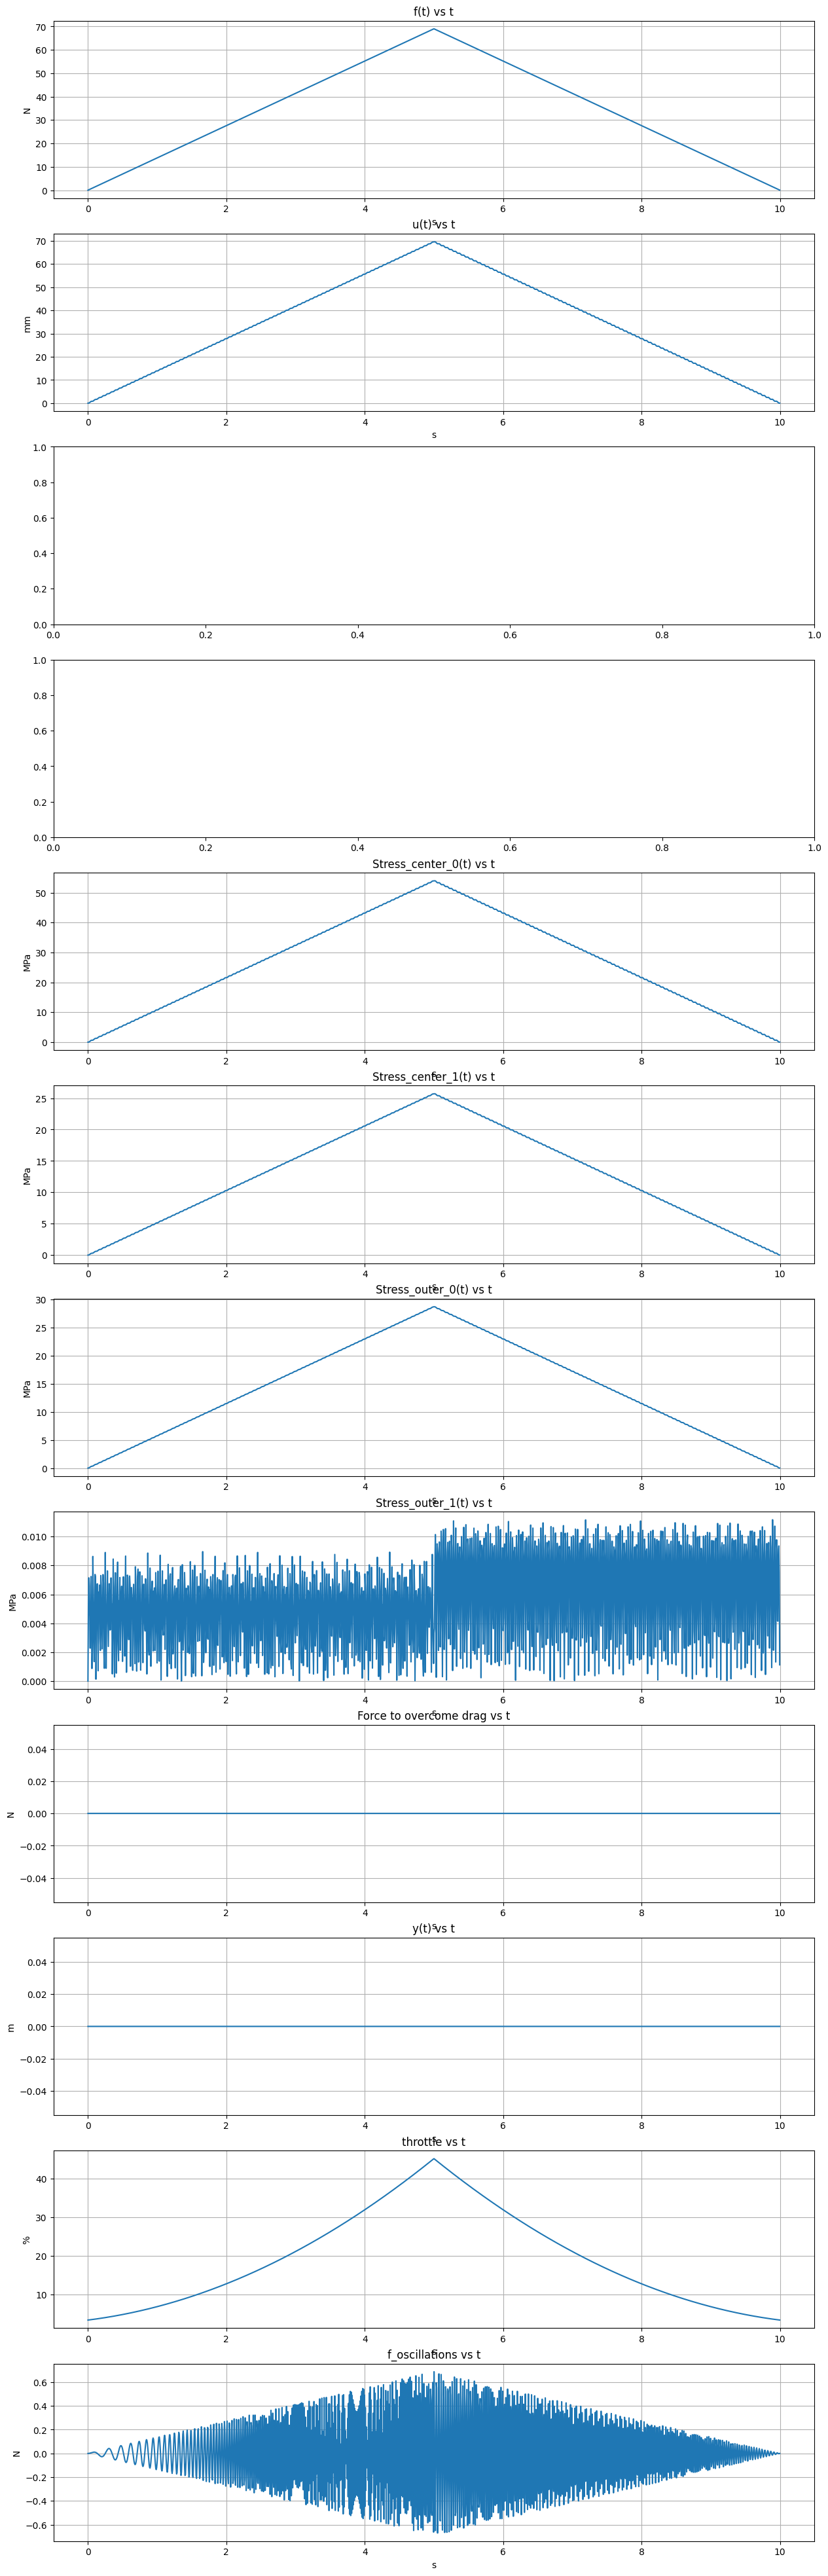

In [4]:

drone_power = DronePower(8, battery_sys.milliwatt_hours, total_force_y, list_t)
drone_power.energy_consumption_calc()
drone_power.throttle_ratio_trans_calc(16)

fig, axs = plt.subplots(12,1)

fig.set_figheight(50)
fig.set_figwidth(15)


tip_node = d1_fea.beam_system.select_node("outer_node")
center_beam = d1_fea.beam_system.select_element("center_beam")
outer_beam = d1_fea.beam_system.select_element("outer_beam")

axs[0].set_title("f(t) vs t")
axs[0].plot(list_t, d1_fea.beam_system.z_forces_ts[:,tip_node])
axs[0].grid()
axs[0].set_ylabel("N")
axs[0].set_xlabel("s")

axs[1].set_title("u(t) vs t")
axs[1].plot(list_t, d1_fea.beam_system.z_displacements_ts[:,tip_node])
axs[1].grid()
axs[1].set_ylabel("mm")
axs[1].set_xlabel("s")


axs[4].set_title("Stress_center_0(t) vs t")
axs[4].plot(list_t, d1_fea.beam_system.beams[center_beam].bending_stresses_0_ts)
axs[4].grid()
axs[4].set_ylabel("MPa")
axs[4].set_xlabel("s")

axs[5].set_title("Stress_center_1(t) vs t")
axs[5].plot(list_t, d1_fea.beam_system.beams[center_beam].bending_stresses_1_ts)
axs[5].grid()
axs[5].set_ylabel("MPa")
axs[5].set_xlabel("s")

axs[6].set_title("Stress_outer_0(t) vs t")
axs[6].plot(list_t, d1_fea.beam_system.beams[outer_beam].bending_stresses_0_ts)
axs[6].grid()
axs[6].set_ylabel("MPa")
axs[6].set_xlabel("s")

axs[7].set_title("Stress_outer_1(t) vs t")
axs[7].plot(list_t, d1_fea.beam_system.beams[outer_beam].bending_stresses_1_ts)
axs[7].grid()
axs[7].set_ylabel("MPa")
axs[7].set_xlabel("s")

axs[8].set_title("Force to overcome drag vs t")
axs[8].plot(list_t, drag)
axs[8].grid()
axs[8].set_ylabel("N")
axs[8].set_xlabel("s")

axs[9].set_title("y(t) vs t")
axs[9].plot(list_t, position/1000)
axs[9].grid()
axs[9].set_ylabel("m")
axs[9].set_xlabel("s")

axs[10].set_title("throttle vs t")
axs[10].plot(list_t, drone_power.percent_throttle * 100)
axs[10].grid()
axs[10].set_ylabel("%")
axs[10].set_xlabel("s")

axs[11].set_title("f_oscillations vs t")
axs[11].plot(list_t, oscillations)
axs[11].grid()
axs[11].set_ylabel("N")
axs[11].set_xlabel("s")

# Check drag function
# pandas
# Vibration from motors: F(t) = sin(w(t) * t) * f(t) * 0.1
# dt = 2 * rpm
# segments

ValueError: x and y must have same first dimension, but have shapes (0,) and (100,)

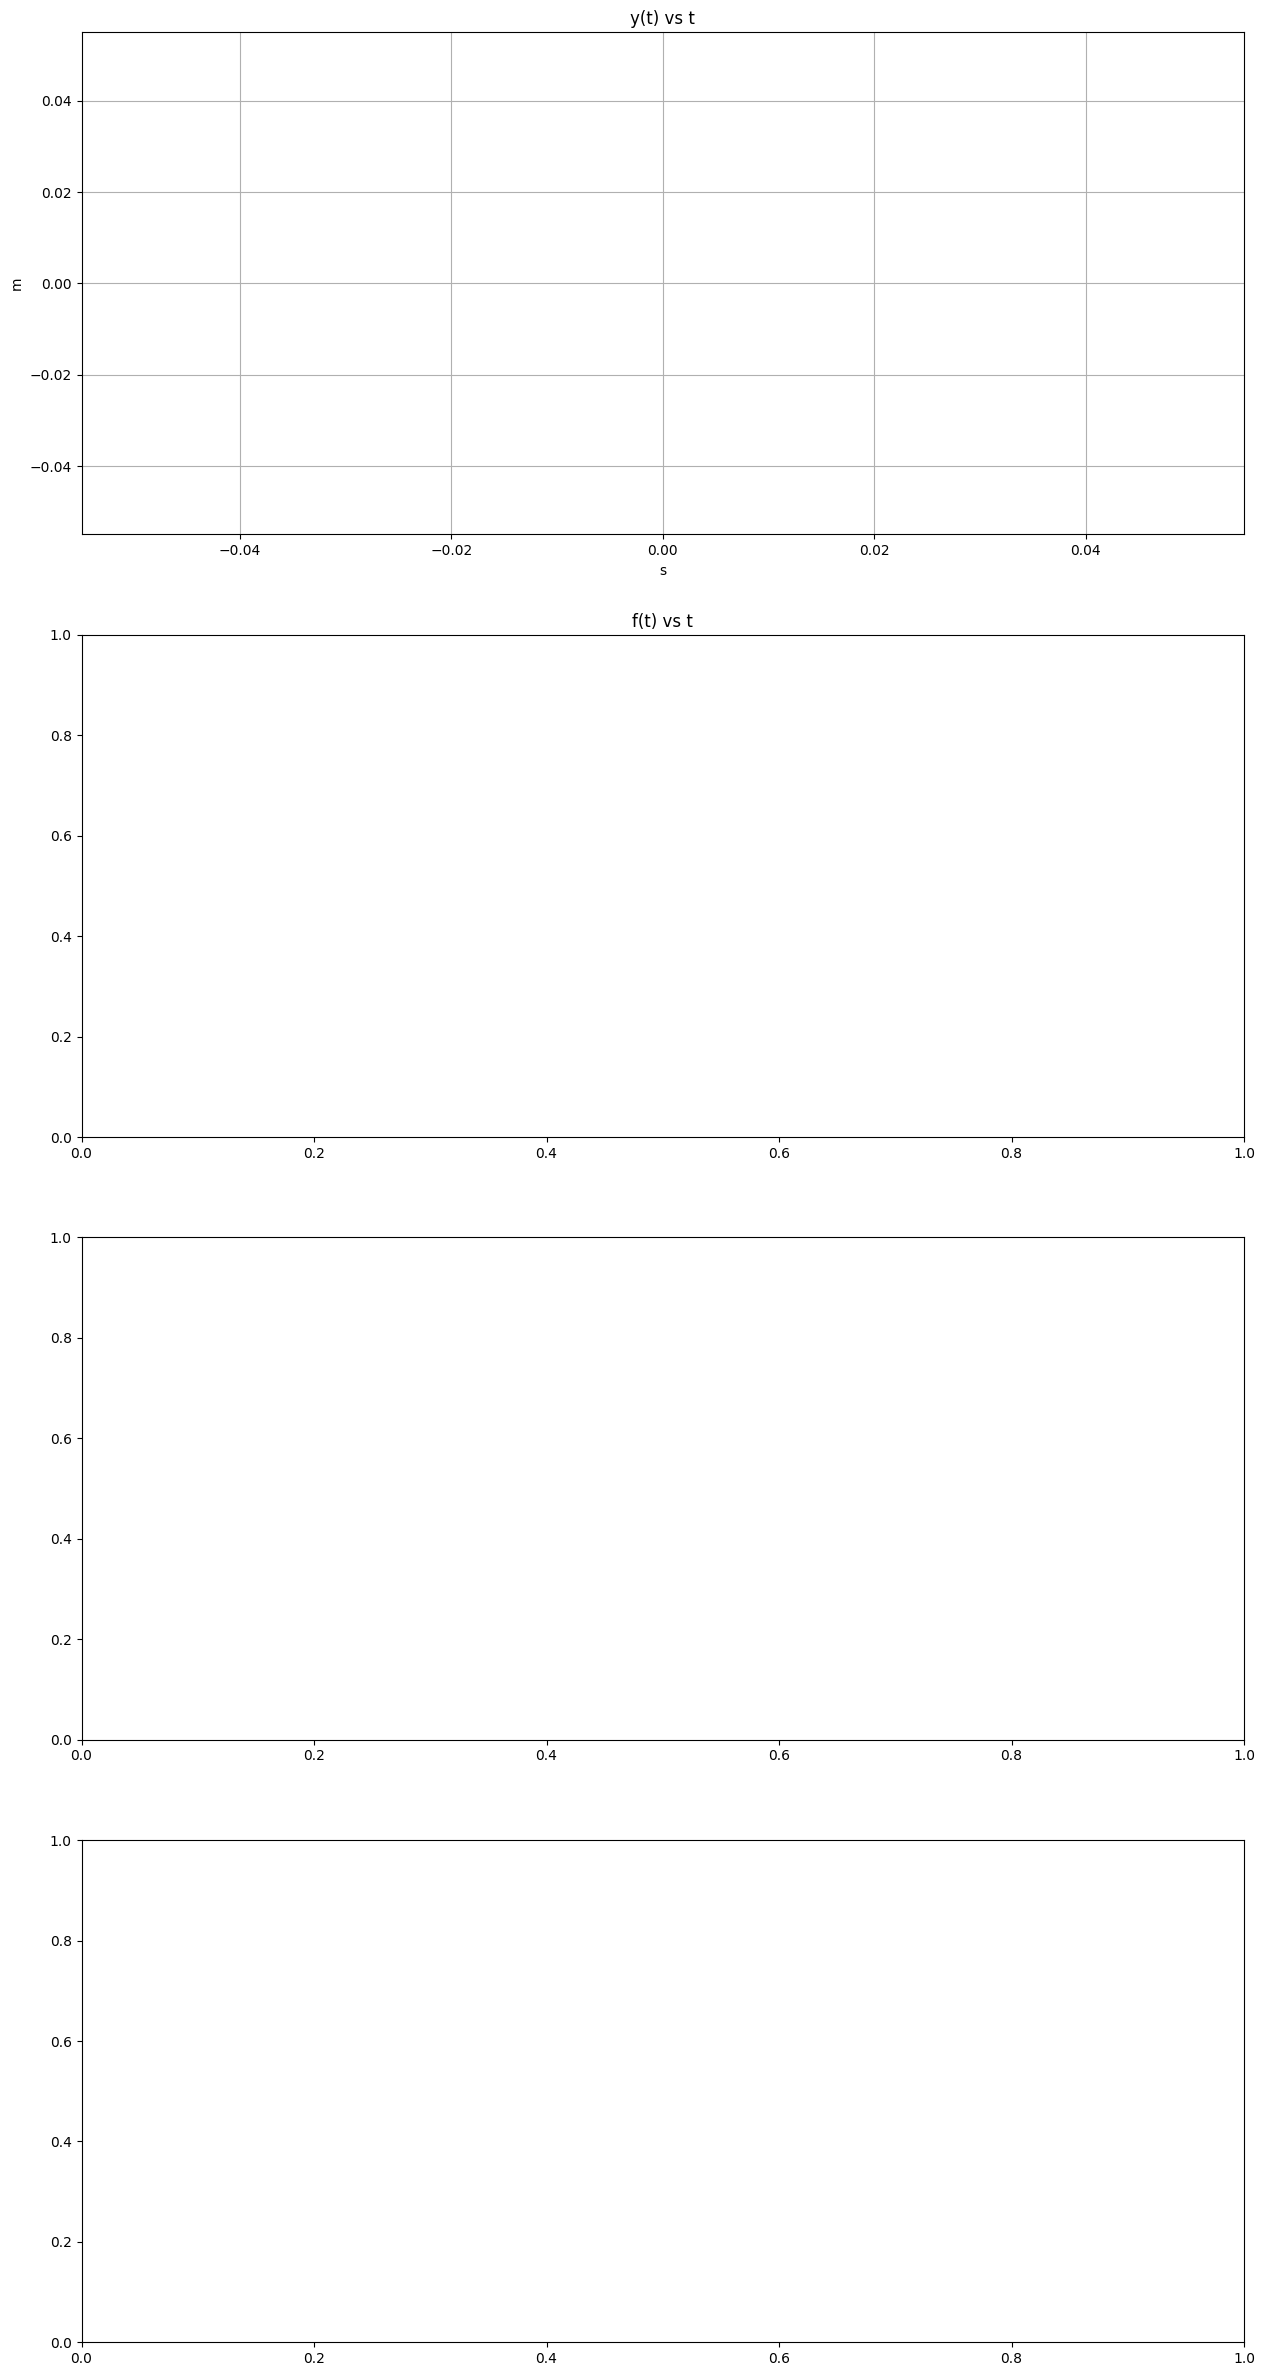

In [5]:
list_t_2 = np.arange(0, m1.duration-q, q)


x = np.zeros(len(list_t_2))
y = np.zeros(len(list_t_2))
v_x = np.zeros(len(list_t_2))
v_y = np.zeros(len(list_t_2))
a_x = np.zeros(len(list_t_2))
a_y = np.zeros(len(list_t_2))

for i, t in enumerate(list_t_2):
    p, v, a = m1.time_solve(t)
    x[i] = p[0]
    y[i] = p[1]
    v_x[i] = v[0]
    v_y[i] = v[1]
    a_x[i] = a[0]
    a_y[i] = a[1]

fig, axs = plt.subplots(4,1)

fig.set_figheight(30)
fig.set_figwidth(15)



axs[0].set_title("y(t) vs t")
axs[0].plot(list_t_2[0:100], y[0:100]/1000)
axs[0].grid()
axs[0].set_ylabel("m")
axs[0].set_xlabel("s")

axs[1].set_title("f(t) vs t")
axs[1].plot(list_t_2[0:100], d1_fea.beam_system.z_forces_ts[:,2][0:100])
axs[1].grid()
axs[1].set_ylabel("N")
axs[1].set_xlabel("s")

axs[2].set_title("u(t) vs t")
axs[2].plot(list_t_2[0:100], d1_fea.beam_system.z_displacements_ts[:,2][0:100])
axs[2].grid()
axs[2].set_ylabel("mm")
axs[2].set_xlabel("s")


axs[3].set_title("Stress(t) vs t")
axs[3].plot(list_t_2[0:100], d1_fea.beam_system.beams[0].bending_stresses_0_ts[0:100])
axs[3].grid()
axs[3].set_ylabel("MPa")
axs[3].set_xlabel("s")


In [1]:
import numpy as np
import pandas as pd

import pylife.stress.rainflow as RF

woehler_curve_data = pd.Series({
    'SD': 340,
    'ND': 5e8,
    'k_1': 6.4 # What is this?
})

stress_curve = d1_fea.beam_system.beams[0].bending_stresses_0_ts
# No clue what this does something with rain counting
detector = RF.FourPointDetector(recorder=RF.LoopValueRecorder())
detector.process(stress_curve)

collective = detector.recorder.collective
cl = collective.load_collective

print(cl.cycles)
print(cl.amplitude)

print(woehler_curve_data.fatigue.damage(cl).sum())

NameError: name 'd1_fea' is not defined

In [21]:
import pandas as pd

def actual_seg_at_time(t):
    if t < rev_time:
        return "revving up"
    elif t < rev_time + m1.duration:
        return m1.segment_name_at_time(t-rev_time)
    else:
        return "winding down"

t_values = np.arange(0, list_t[-1]+1, 1)

# Create DataFrame
fmp = pd.DataFrame( {
    "time": t_values,
    "force_mission_profile": [force_transient(t)[2] for t in t_values],
    "segment": [actual_seg_at_time(t) for t in t_values]
})

# Export to Excel
fmp.to_csv("force_mission_profile.csv", index=False)

t_values = np.arange(0, list_t[-1]+0.01, 0.01)

# Create DataFrame
fo = pd.DataFrame( {
    "time": t_values,
    "force_oscillations": [oscillation(t) for t in t_values],
    "segment": [actual_seg_at_time(t) for t in t_values]
})

# Export to Excel
fo.to_csv("force_oscillations.csv", index=False)

np.float64(47.6028532112564)

array([ 0.,  0., -0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0., -0.,  0.,
        0.,  0.])